In [10]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings



warnings.filterwarnings('ignore')

In [11]:
df = pd.read_csv(r'F:\zizo\RTKCorrection\src\research\data\training\data.csv')
df.head()

,GPST,avg_snr,min_snr,max_residual,x_x,y_x,z_x,ns,sdx(m),sdy(m),sdz(m),sdxy(m),sdyz(m),sdzx(m),x_y,y_y,z_y,diff_x,diff_y,diff_z
0,2023-12-06 01:59:08,31.750000,26.0,1.6368,459252.2586,5.634018e+06,2.947007e+06,8.0,52.2081,36.9664,49.3526,40.7052,-37.1917,-50.0592,459291.9968,5.634082e+06,2.946966e+06,39.7382,64.6765,-40.9517
1,2023-12-06 01:59:09,31.625000,25.0,1.7018,459252.7407,5.634016e+06,2.947006e+06,8.0,52.2223,36.9710,49.3521,40.7137,-37.1948,-50.0660,459289.5836,5.634087e+06,2.946966e+06,36.8429,71.1549,-39.4826
2,2023-12-06 01:59:49,29.000000,23.0,5.5528,459308.8238,5.634051e+06,2.946946e+06,11.0,10.2943,17.0425,16.1441,3.2766,10.4717,-11.0646,459295.8737,5.634077e+06,2.946962e+06,-12.9501,26.0052,16.4584
3,2023-12-06 02:06:09,27.500000,19.0,11.0868,459293.8285,5.634046e+06,2.946964e+06,16.0,4.6884,16.7968,9.3480,-2.4012,11.4236,-3.5037,459293.3256,5.634080e+06,2.946963e+06,-0.5029,34.6117,-0.4802
4,2023-12-06 02:06:25,27.666667,16.0,11.5613,459294.7681,5.634057e+06,2.946969e+06,15.0,4.6947,17.2442,9.9720,-2.3391,12.0011,-3.4614,459285.2562,5.634097e+06,2.946964e+06,-9.5119,39.3426,-5.2728


In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

def train_ensemble_and_evaluate(df, feature_cols):
    # --- Data prep ---
    X = df[feature_cols]
    y = df[['x_y', 'y_y', 'z_y']]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train_scaled = x_scaler.fit_transform(X_train)
    X_test_scaled = x_scaler.transform(X_test)
    y_train_scaled = y_scaler.fit_transform(y_train)

    # --- Fixed Random Forest (BEST PARAMS) ---
    print(f"\n{'='*80}\nTRAINING RANDOM FOREST (FIXED HYPERPARAMETERS)\n{'='*80}")

    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=20,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train_scaled, y_train_scaled)

    # --- Make predictions ---
    y_pred_scaled = rf.predict(X_test_scaled)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)
    y_test_vals = y_test.to_numpy()

    # --- Evaluation ---
    print("\n" + "="*80 + "\nFINAL EVALUATION: RANDOM FOREST\n" + "="*80)
    per_axis_rmse = []

    for i, axis in enumerate(['X', 'Y', 'Z']):
        rmse = np.sqrt(mean_squared_error(y_test_vals[:, i], y_pred[:, i]))
        per_axis_rmse.append(rmse)
        print(
            f"--- Axis {axis} ---\n"
            f"  R² Score: {r2_score(y_test_vals[:, i], y_pred[:, i]):.4f}\n"
            f"  RMSE (m): {rmse:.4f}\n"
        )

    print(f"Overall mean RMSE (m): {np.mean(per_axis_rmse):.4f}")

    # --- Feature importance ---
    plt.figure(figsize=(10, 6))
    importances = rf.feature_importances_
    indices = np.argsort(importances)[::-1]

    plt.title("Random Forest Feature Importance", fontsize=16)
    plt.bar(range(len(importances)), importances[indices])
    plt.xticks(
        range(len(importances)),
        [feature_cols[i] for i in indices],
        rotation=45
    )
    plt.tight_layout()
    plt.show()

    return rf, x_scaler, y_scaler, X_test, y_pred


In [13]:
def calculate_accuracy_improvement(test_df, y_pred_corrected, spp_cols):
    """Calculates and prints before-and-after 3D and per-axis error comparison."""

    spp_x_col, spp_y_col, spp_z_col = spp_cols

    # ===============================
    # Original Errors
    # ===============================
    original_diff_x = test_df['x_x'] - test_df['x_y']
    original_diff_y = test_df['y_x'] - test_df['y_y']
    original_diff_z = test_df['z_x'] - test_df['z_y']

    # original 3D error (Euclidean distance)
    original_3d_errors = np.sqrt(
        original_diff_x**2 +
        original_diff_y**2 +
        original_diff_z**2
    )
    mean_original_3d = original_3d_errors.mean()

    # Mean absolute error per axis (original)
    mean_orig_x = np.abs(original_diff_x).mean()
    mean_orig_y = np.abs(original_diff_y).mean()
    mean_orig_z = np.abs(original_diff_z).mean()

    # ===============================
    # Corrected SPP coordinates
    # ===============================
    corrected_spp_x = y_pred_corrected[:, 0]
    corrected_spp_y = y_pred_corrected[:, 1]
    corrected_spp_z = y_pred_corrected[:, 2]

    # Corrected residuals
    corrected_diff_x = test_df['x_y'] - corrected_spp_x
    corrected_diff_y = test_df['y_y'] - corrected_spp_y
    corrected_diff_z = test_df['z_y'] - corrected_spp_z

    corrected_3d_errors = np.sqrt(
        corrected_diff_x**2 +
        corrected_diff_y**2 +
        corrected_diff_z**2
    )

    mean_corrected_3d = corrected_3d_errors.mean()

    # Mean absolute error per axis (corrected)
    mean_corr_x = np.abs(corrected_diff_x).mean()
    mean_corr_y = np.abs(corrected_diff_y).mean()
    mean_corr_z = np.abs(corrected_diff_z).mean()

    # ===============================
    # Improvements
    # ===============================
    improvement_3d = mean_original_3d - mean_corrected_3d
    improvement_3d_pct = (
        improvement_3d / mean_original_3d * 100
        if mean_original_3d != 0 else 0
    )

    # Per-axis improvements
    imp_x = mean_orig_x - mean_corr_x
    imp_y = mean_orig_y - mean_corr_y
    imp_z = mean_orig_z - mean_corr_z

    # ===============================
    # Print results
    # ===============================
    print("\n" + "="*80)
    print("MODEL ACCURACY IMPROVEMENT ANALYSIS")
    print("="*80)

    print(f"\n--- 3D POSITION ERROR ---")
    print(f"Mean 3D Error (Original):  {mean_original_3d:.4f} m")
    print(f"Mean 3D Error (Corrected): {mean_corrected_3d:.4f} m")
    print(f"Improvement: {improvement_3d:.4f} m ({improvement_3d_pct:.2f}%)")

    print(f"\n--- PER-AXIS MEAN ABSOLUTE ERROR ---")
    print(f"X-axis: {mean_orig_x:.4f} → {mean_corr_x:.4f} m  (Δ {imp_x:.4f} m)")
    print(f"Y-axis: {mean_orig_y:.4f} → {mean_corr_y:.4f} m  (Δ {imp_y:.4f} m)")
    print(f"Z-axis: {mean_orig_z:.4f} → {mean_corr_z:.4f} m  (Δ {imp_z:.4f} m)")


In [14]:
df[['x_y', 'y_y', 'z_y']].describe()

,x_y,y_y,z_y
count,139632.000000,1.396320e+05,1.396320e+05
mean,459863.392528,5.634222e+06,2.946557e+06
std,374.183148,1.346761e+02,2.224990e+02
min,459247.085100,5.633903e+06,2.945778e+06
25%,459659.688500,5.634131e+06,2.946481e+06
50%,459729.645350,5.634236e+06,2.946561e+06
75%,459937.236775,5.634293e+06,2.946725e+06
max,460834.264400,5.634609e+06,2.947006e+06


In [15]:
from sklearn.ensemble import IsolationForest

# Ensure diff columns exist
cols = ['x_y', 'y_y', 'z_y']
missing = [c for c in cols if c not in df.columns]
if missing:
    raise KeyError(f'Missing required diff columns in df: {missing}')

# Handle NaNs directly in df (fill with median)
df[cols] = df[cols].fillna(df[cols].median())

# Train IsolationForest on the diff columns
iso = IsolationForest(
    n_estimators=500,
    contamination='auto',
    random_state=42,
    n_jobs=-1
)
iso.fit(df[cols])

# Predict anomalies (-1 = anomaly, 1 = normal)
df['anomaly'] = iso.predict(df[cols])

# Print summary
print('Anomaly value counts (1 = normal, -1 = anomaly):')
print(df['anomaly'].value_counts())


Anomaly value counts (1 = normal, -1 = anomaly):
anomaly
 1    86169
-1    53463
Name: count, dtype: int64


In [16]:
df = df[df['anomaly'] == 1].drop(columns=['anomaly'])
print(f"Data size before cleaning: {len(df)}")

Data size before cleaning: 86169


In [17]:
df[['x_y', 'y_y', 'z_y']].describe()

,x_y,y_y,z_y
count,86169.000000,8.616900e+04,8.616900e+04
mean,459697.362548,5.634235e+06,2.946569e+06
std,176.550113,6.658788e+01,1.171016e+02
min,459358.914800,5.634045e+06,2.946267e+06
25%,459625.166000,5.634205e+06,2.946504e+06
50%,459687.638100,5.634244e+06,2.946550e+06
75%,459734.677200,5.634276e+06,2.946600e+06
max,460467.090700,5.634394e+06,2.946818e+06



TRAINING RANDOM FOREST (FIXED HYPERPARAMETERS)

FINAL EVALUATION: RANDOM FOREST
--- Axis X ---
  R² Score: 0.9998
  RMSE (m): 2.4233

--- Axis Y ---
  R² Score: 0.9960
  RMSE (m): 4.2538

--- Axis Z ---
  R² Score: 0.9995
  RMSE (m): 2.6420

Overall mean RMSE (m): 3.1064


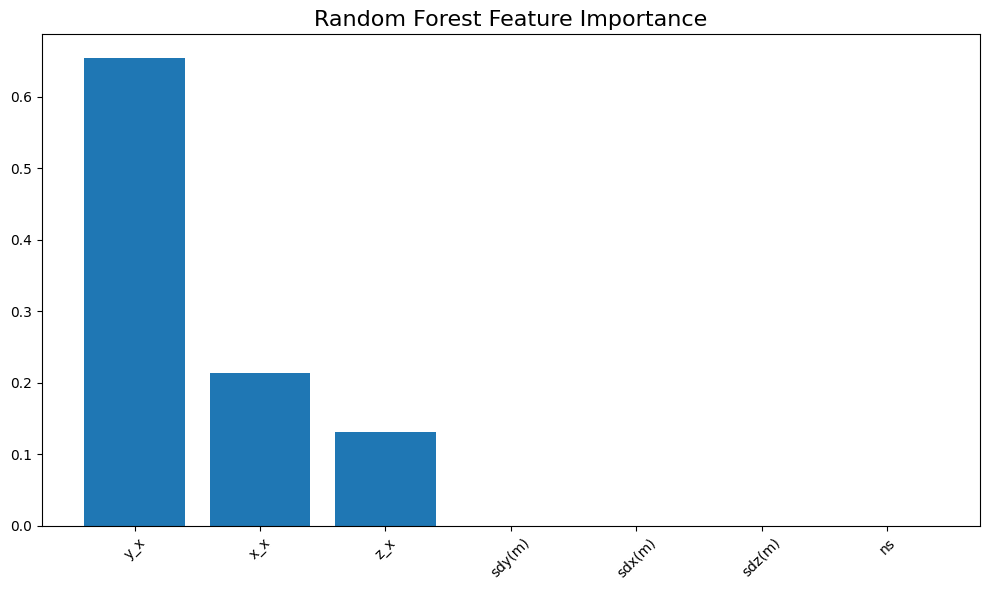


MODEL ACCURACY IMPROVEMENT ANALYSIS

--- 3D POSITION ERROR ---
Mean 3D Error (Original):  14.9509 m
Mean 3D Error (Corrected): 4.0745 m
Improvement: 10.8763 m (72.75%)

--- PER-AXIS MEAN ABSOLUTE ERROR ---
X-axis: 2.8104 → 1.4825 m  (Δ 1.3279 m)
Y-axis: 10.6260 → 2.7759 m  (Δ 7.8502 m)
Z-axis: 8.8424 → 1.7793 m  (Δ 7.0631 m)


'\njoblib.dump(best_models, \'best_gnss_model.joblib\')\njoblib.dump(x_scaler, \'x_scaler.joblib\')\njoblib.dump(y_scaler, \'y_scaler.joblib\')\njoblib.dump(feature_cols, \'feature_cols.joblib\')\nprint("\n✓ Best model, scaler, and feature list saved successfully!")\nprint("\n✓ Analysis complete!")'

In [18]:
    # 2) train simple Neural Network (BatchNorm + Dropout)
    # Think of it like asking multiple experts for their opinion and averaging their answers.
best_models, x_scaler, y_scaler, X_test, y_pred = train_ensemble_and_evaluate(df, ['x_x', 'y_x', 'z_x', 'ns', 'sdx(m)', 'sdy(m)', 'sdz(m)'])
test_df = df.loc[X_test.index]
spp_x, spp_y, spp_z = 'x_x', 'y_x', 'z_x'  # Assuming these are the SPP columns in test_df
calculate_accuracy_improvement(test_df, y_pred, (spp_x, spp_y, spp_z))
"""
    joblib.dump(best_models, 'best_gnss_model.joblib')
    joblib.dump(x_scaler, 'x_scaler.joblib')
    joblib.dump(y_scaler, 'y_scaler.joblib')
    joblib.dump(feature_cols, 'feature_cols.joblib')
    print("\n✓ Best model, scaler, and feature list saved successfully!")
    print("\n✓ Analysis complete!")"""